In [150]:
# Loading stuff

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import uuid
%matplotlib inline

## Data exploration and analysis

Here we:
- Loaded the datasets
- Dropped all object type colmns composed only by unique values
- Dropped all columns composed by the same value for all rows
- Encoded the target variable
- Dropped non-target columns with high correlation between them
- Droppped columns with low correlation with the target variable


In [151]:
# --- Loading all the datasets

# Train dataset
train_dataset = pd.read_csv('data/train_radiomics_hipocamp.csv')

# Test dataset
test_dataset = pd.read_csv('data/test_radiomics_hipocamp.csv')

# Control dataset
control_dataset = pd.read_csv('data/train_radiomics_occipital_CONTROL.csv')

In [152]:
# --- Exploring the train dataset

train_dataset.head()
train_dataset.columns
train_dataset.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 2181 columns):
 #     Column                                                         Non-Null Count  Dtype  
---    ------                                                         --------------  -----  
 0     ID                                                             305 non-null    object 
 1     Image                                                          305 non-null    object 
 2     Mask                                                           305 non-null    object 
 3     diagnostics_Versions_PyRadiomics                               305 non-null    object 
 4     diagnostics_Versions_Numpy                                     305 non-null    object 
 5     diagnostics_Versions_SimpleITK                                 305 non-null    object 
 6     diagnostics_Versions_PyWavelet                                 305 non-null    object 
 7     diagnostics_Versions_Python             

In [153]:
# --- Dropping al column type object composed only by unique values

# Getting all columns whose value is an object
obj_col = train_dataset.select_dtypes(include='object').columns

# For each of those, checking the number of unique values
# Storing in a list the columns that have the same number of unique values as the number of rows
# This means that the column is a unique identifier and probably should be dropped,as it does not provide 
# valuable information
unique_cols = []
for col in obj_col:
    if train_dataset[col].nunique() == 305:
        unique_cols.append(col)

# Creating and displaying a dataframe containing only the columns stored in the above list
unique_df = train_dataset[unique_cols]
unique_df.head()

# We don't want to drop the ID column right now
unique_cols.remove('ID')

# We can confirm all the columns in the unique_df dataframe are unique identifiers that don't provide any useful information
# Dropping the columns stored in the unique_cols list
train_dataset.drop(unique_cols, axis=1, inplace=True)
# Dropping them from the test dataset as well
test_dataset.drop(unique_cols, axis=1, inplace=True)


In [154]:
# --- Dropping all collumns with only one unique value

only_one_unique_val_col = 0
for col in train_dataset.columns:
    if train_dataset[col].nunique() == 1:
        only_one_unique_val_col += 1
        train_dataset.drop(col, axis=1, inplace=True)
        # Dropping them from the test dataset as well
        test_dataset.drop(col, axis=1, inplace=True)

print("dropped " + str(only_one_unique_val_col) + " columns")
        

dropped 159 columns


In [155]:
# Checking all unique values in the Transition column
train_dataset['Transition'].value_counts()
# Dataset is extremely UNBALANCED

Transition
CN-CN      96
MCI-MCI    71
MCI-AD     68
AD-AD      60
CN-MCI     10
Name: count, dtype: int64

In [156]:
# --- Using encoding to transform the categorical columns into numerical columns
replace_map = {'Transition': {'CN-CN': 0, 'AD-AD': 1, 'CN-MCI': 2, 'MCI-AD': 3, 'MCI-MCI': 4}}
train_dataset.replace(replace_map, inplace=True)
test_dataset.replace(replace_map, inplace=True)
train_dataset.head()

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_8112\4011534618.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_dataset.replace(replace_map, inplace=True)


,ID,diagnostics_Image-original_Mean,diagnostics_Image-original_Maximum,diagnostics_Mask-original_VoxelNum,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,...,lbp-3D-k_glszm_ZonePercentage,lbp-3D-k_glszm_ZoneVariance,lbp-3D-k_ngtdm_Busyness,lbp-3D-k_ngtdm_Coarseness,lbp-3D-k_ngtdm_Complexity,lbp-3D-k_ngtdm_Contrast,lbp-3D-k_ngtdm_Strength,Sex,Age,Transition
0,006_S_0681,5.848123,178,7106,0.420040,0.106547,10.757474,100.964915,72.034714,71.175839,...,0.007881,345733.167092,479.414935,0.001538,0.183049,0.017044,0.001581,0,77.1,0
1,941_S_1203,5.238834,190,7779,0.425482,0.102532,10.432362,101.747321,73.246160,73.109507,...,0.013112,244310.331892,378.001763,0.001761,0.146021,0.010782,0.001813,1,83.4,0
2,011_S_0003,6.816667,155,6707,0.447685,0.135582,14.370911,105.993915,79.762146,79.056942,...,0.011331,222776.529605,497.261162,0.001567,0.190309,0.019644,0.001596,1,81.3,1
3,057_S_0779,6.445162,171,8281,0.418896,0.099626,10.639815,106.797600,78.102497,77.006493,...,0.012197,280222.663268,406.837667,0.001629,0.148247,0.010824,0.001677,1,79.6,2
4,033_S_0920,5.568269,150,5986,0.411851,0.080719,8.885188,110.075144,75.432089,75.239617,...,0.010859,216779.591479,368.838125,0.001912,0.174701,0.014793,0.001979,0,80.1,0


In [157]:
# Oversampling the minority class
# we need to ignore the ID column
# and generate a new ID for the new samples
# we will use the SMOTE algorithm
smote = SMOTE(sampling_strategy='minority', random_state=42)
X = train_dataset.drop(['Transition','ID'], axis=1)
y = train_dataset['Transition']
X_resampled, y_resampled = smote.fit_resample(X, y)
X_resampled['ID'] = [uuid.uuid4() for _ in range(len(X_resampled))]
X_resampled['Transition'] = y_resampled
train_dataset = X_resampled

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_8112\3311884656.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_resampled['ID'] = [uuid.uuid4() for _ in range(len(X_resampled))]
C:\Users\Utilizador\AppData\Local\Temp\ipykernel_8112\3311884656.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_resampled['Transition'] = y_resampled


In [158]:
# Checking all unique values in the Transition column
train_dataset['Transition'].value_counts()

Transition
0    96
2    96
4    71
3    68
1    60
Name: count, dtype: int64

In [159]:
# Dataset is still a little unbalanced.
# [TEST THIS] Might be better to just get 60 samples from each class
train_dataset = train_dataset.groupby('Transition').apply(lambda x: x.sample(n=60)).reset_index(drop=True)
train_dataset['Transition'].value_counts()

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_8112\2766346282.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_dataset = train_dataset.groupby('Transition').apply(lambda x: x.sample(n=60)).reset_index(drop=True)


Transition
0    60
1    60
2    60
3    60
4    60
Name: count, dtype: int64

In [160]:
## --- Droppig non-target columns with high correlation with each-other
#
#target_column = 'Transition'  
## Calculating the correlation matrix (excluding the target column and the ID column)
#train_dataset_tmp = train_dataset 
#corr_matrix_train = train_dataset_tmp.drop(columns=[target_column, 'ID']).corr().abs()
#corr_matrix_test = test_dataset.drop(columns=['ID']).corr().abs()
#
## Upper triangle matrix of correlations
#upper = corr_matrix_train.where(np.triu(np.ones(corr_matrix_train.shape), k=1).astype(bool))
#
## Finding index of feature columns with correlation greater than 0.92
#threshold = 0.92
#to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
#
## Dropping the columns
#train_dataset = train_dataset.drop(columns=to_drop)
#test_dataset = test_dataset.drop(columns=to_drop)

## !!! I think this needs to be dropped, but we should test it because prof was talking about not removing columns

In [161]:
# Checking dataset info
train_dataset.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 2015 columns):
 #     Column                                                         Non-Null Count  Dtype  
---    ------                                                         --------------  -----  
 0     diagnostics_Image-original_Mean                                300 non-null    float64
 1     diagnostics_Image-original_Maximum                             300 non-null    int64  
 2     diagnostics_Mask-original_VoxelNum                             300 non-null    int64  
 3     original_shape_Elongation                                      300 non-null    float64
 4     original_shape_Flatness                                        300 non-null    float64
 5     original_shape_LeastAxisLength                                 300 non-null    float64
 6     original_shape_MajorAxisLength                                 300 non-null    float64
 7     original_shape_Maximum2DDiameterColumn  

In [162]:
# --- Dropping columns with low correlation with the target column (<0.005)

# corr_matrix = train_dataset.corr()
# corr_target = corr_matrix['Transition'].abs()
# uncorr_cols = []
# for i in range(len(corr_target)):
#     if corr_target[i] < 0.005:
#         uncorr_cols.append(corr_matrix.columns[i])
# 
# # Dropping the columns stored in the uncorr_cols list
# n_cols_before = len(train_dataset.columns)
# train_dataset.drop(uncorr_cols, axis=1, inplace=True)
# test_dataset.drop(uncorr_cols, axis=1, inplace=True)
# n_cols_after = len(train_dataset.columns)
# 
# print("Dropped " + str(n_cols_before-n_cols_after) + " columns!")

# ---

Axes(0.125,0.11;0.775x0.77)


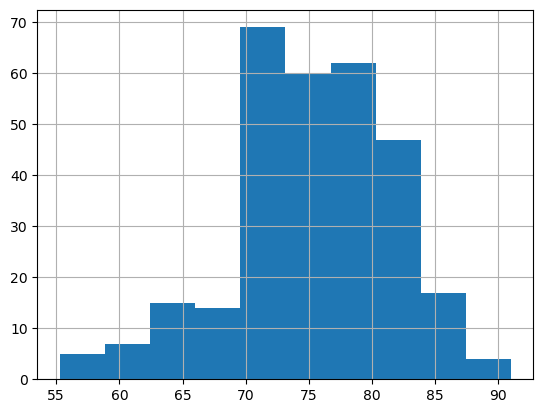

In [163]:
# Checking Age column
print(train_dataset['Age'].hist())
plt.show()
# Not a normal distribution

In [164]:
# Checking Sex column
print(train_dataset['Sex'].value_counts(normalize=True))
# Not quite balanced

Sex
1    0.52
0    0.48
Name: proportion, dtype: float64


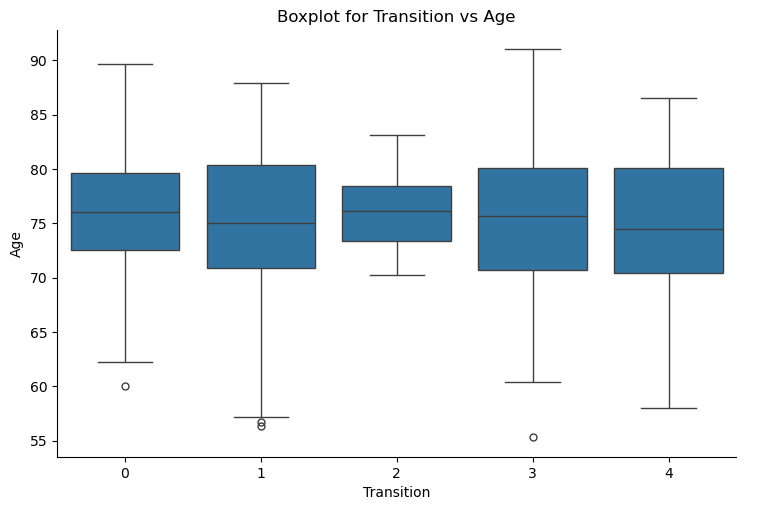

In [165]:
# Understanding the relationship between Age and Transition
sns.catplot(x="Transition", y="Age", data=train_dataset, kind="box", aspect=1.5)
plt.title("Boxplot for Transition vs Age")
plt.show()

In [166]:
train_dataset.head()

,diagnostics_Image-original_Mean,diagnostics_Image-original_Maximum,diagnostics_Mask-original_VoxelNum,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,...,lbp-3D-k_glszm_ZoneVariance,lbp-3D-k_ngtdm_Busyness,lbp-3D-k_ngtdm_Coarseness,lbp-3D-k_ngtdm_Complexity,lbp-3D-k_ngtdm_Contrast,lbp-3D-k_ngtdm_Strength,Sex,Age,ID,Transition
0,6.268191,203,7269,0.401673,0.101371,10.835627,106.890712,77.414469,77.233412,42.720019,...,270974.110643,438.460201,0.001615,0.170377,0.014580,0.001667,1,72.2,7df442e6-2973-47bc-bbfe-44894a3d32fe,0
1,5.762394,138,5901,0.409123,0.108146,10.543082,97.489358,69.180922,69.065187,38.832976,...,245257.015432,414.000667,0.001796,0.188752,0.017758,0.001856,0,71.3,9f20b5a6-5690-4f4f-9a3c-42c2fcaa7f9a,0
2,5.461443,174,7338,0.412408,0.078839,9.036728,114.622485,82.200973,82.152298,47.413078,...,254916.039116,438.191155,0.001606,0.169722,0.014367,0.001654,1,87.3,0dfa723b-1599-40ba-b889-3bd74abedf52,0
3,6.127670,160,6208,0.418651,0.112794,12.145361,107.677335,77.524190,78.006410,48.373546,...,208815.096421,342.954795,0.002004,0.160749,0.012895,0.002064,1,80.4,03ae4b20-9382-4219-8a28-894909a38c30,0
4,5.778956,128,7832,0.422420,0.088513,9.610490,108.577302,78.089692,76.321688,46.227697,...,386892.734375,412.274838,0.001648,0.154989,0.012073,0.001697,0,70.7,5f3fc094-db52-4315-aaef-4fce045fd1ce,0


In [167]:
# Treating outliers in all columns
# Outliers should be converted to the median value of the column
changes_count = 0

for col in train_dataset.columns:
    if col not in ['Transition', 'ID']:
        median = train_dataset[col].median()
        q1 = train_dataset[col].quantile(0.25)
        q3 = train_dataset[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr # Test different values here
        upper_bound = q3 + 1.5 * iqr
        
        # Count outliers before replacing them
        changes_count += ((train_dataset[col] < lower_bound) | (train_dataset[col] > upper_bound)).sum()
        changes_count += ((test_dataset[col] < lower_bound) | (test_dataset[col] > upper_bound)).sum()
        
        # Replace outliers with the median
        # train_dataset[col] = train_dataset[col].apply(lambda x: median if x < lower_bound or x > upper_bound else x)
        # test_dataset[col] = test_dataset[col].apply(lambda x: median if x < lower_bound or x > upper_bound else x)

        # Replace outliers with the closest bound
        train_dataset[col] = train_dataset[col].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)
        test_dataset[col] = test_dataset[col].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)

print(f"Total number of changes made: {changes_count}")


Total number of changes made: 28704


In [168]:
train_dataset.head()

,diagnostics_Image-original_Mean,diagnostics_Image-original_Maximum,diagnostics_Mask-original_VoxelNum,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,...,lbp-3D-k_glszm_ZoneVariance,lbp-3D-k_ngtdm_Busyness,lbp-3D-k_ngtdm_Coarseness,lbp-3D-k_ngtdm_Complexity,lbp-3D-k_ngtdm_Contrast,lbp-3D-k_ngtdm_Strength,Sex,Age,ID,Transition
0,6.268191,203.0,7269.0,0.401673,0.101371,10.835627,106.890712,77.414469,77.233412,42.720019,...,270974.110643,438.460201,0.001615,0.170377,0.014580,0.001667,1,72.2,7df442e6-2973-47bc-bbfe-44894a3d32fe,0
1,5.762394,138.0,5901.0,0.409123,0.108146,10.543082,97.489358,69.180922,69.065187,38.832976,...,245257.015432,414.000667,0.001796,0.188752,0.017758,0.001856,0,71.3,9f20b5a6-5690-4f4f-9a3c-42c2fcaa7f9a,0
2,5.461443,174.0,7338.0,0.412408,0.078839,9.036728,114.622485,82.200973,82.152298,47.413078,...,254916.039116,438.191155,0.001606,0.169722,0.014367,0.001654,1,87.3,0dfa723b-1599-40ba-b889-3bd74abedf52,0
3,6.127670,160.0,6208.0,0.418651,0.112794,12.144419,107.677335,77.524190,78.006410,48.373546,...,208815.096421,342.954795,0.002004,0.160749,0.012895,0.002064,1,80.4,03ae4b20-9382-4219-8a28-894909a38c30,0
4,5.778956,128.0,7832.0,0.422420,0.088513,9.610490,108.577302,78.089692,76.321688,46.227697,...,386892.734375,412.274838,0.001648,0.154989,0.012073,0.001697,0,70.7,5f3fc094-db52-4315-aaef-4fce045fd1ce,0


In [169]:
test_dataset.head()

,ID,diagnostics_Image-original_Mean,diagnostics_Image-original_Maximum,diagnostics_Mask-original_VoxelNum,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,...,lbp-3D-k_glszm_ZoneEntropy,lbp-3D-k_glszm_ZonePercentage,lbp-3D-k_glszm_ZoneVariance,lbp-3D-k_ngtdm_Busyness,lbp-3D-k_ngtdm_Coarseness,lbp-3D-k_ngtdm_Complexity,lbp-3D-k_ngtdm_Contrast,lbp-3D-k_ngtdm_Strength,Sex,Age
0,941_S_1194,5.936274,138.0,6746.0,0.407223,0.096929,10.641164,109.782918,76.400262,76.321688,...,2.882307,0.012155,230174.976800,311.614436,0.002082,0.142371,0.009727,0.002153,1,84.9
1,036_S_0945,6.727111,179.0,8182.0,0.432795,0.096712,10.249435,105.979255,77.103826,78.025637,...,2.724261,0.011611,291753.141939,387.905335,0.001698,0.143956,0.010269,0.001758,1,72.4
2,024_S_1171,6.788788,161.0,7765.0,0.422635,0.107836,11.116675,103.088450,76.006579,80.156098,...,2.625920,0.010947,288449.451903,401.448469,0.001681,0.153188,0.011797,0.001724,1,71.6
3,035_S_0555,6.925492,165.0,8493.0,0.411789,0.104226,11.324564,108.653645,81.024688,82.024387,...,2.609760,0.009302,350725.996795,607.596915,0.001241,0.189832,0.018383,0.001276,1,76.7
4,023_S_0081,5.273378,176.0,7257.0,0.437484,0.099548,10.281734,103.283883,73.389373,71.063352,...,2.890169,0.010197,285390.090029,402.036637,0.001707,0.161413,0.012902,0.001759,1,70.7


In [170]:
# removing ID column
train_dataset.drop('ID', axis=1, inplace=True)
test_dataset.drop('ID', axis=1, inplace=True)

In [171]:
# Saving the treated datasets
train_dataset.to_csv('data/train_dataset_treated.csv', index=False)
test_dataset.to_csv('data/test_dataset_treated.csv', index=False)